This notebook provides a comprehensive analysis of vendor performance. It covers data loading and understanding, KPI exploration, supplier ranking, and dashboard creation for effective decision-making.

# Load Understand the Dataset

This section focuses on loading the vendor performance data and performing initial data quality checks. We will examine the dataset's structure, identify missing values, and check for duplicates to ensure data integrity.

In [19]:
import pandas as pd
import numpy as np

# Load data
try:
    df = pd.read_excel("vendor_performance.xlsx")
except FileNotFoundError:
    print("vendor_performance.xlsx not found. Creating a dummy DataFrame for demonstration.")
    # Create a dummy DataFrame for demonstration if file is not found
    data = {
        'Supplier_ID': range(1, 21),
        'Supplier_Name': [f'Supplier_{i}' for i in range(1, 21)],
        'Region': ['North', 'South', 'East', 'West'] * 5,
        'On_Time_Delivery_%': np.random.uniform(70, 100, 20),
        'Defect_Rate_%': np.random.uniform(0, 10, 20),
        'Avg_Lead_Time_Days': np.random.uniform(5, 30, 20),
        'Fill_Rate_%': np.random.uniform(80, 100, 20),
        'Contract_Compliance_%': np.random.uniform(85, 100, 20),
        'Sustainability_Score': np.random.uniform(50, 100, 20),
        'Response_Time_Hours': np.random.uniform(1, 24, 20),
        'Cost_per_Unit': np.random.uniform(10, 100, 20),
        'Supplier_Risk_Level': np.random.choice(['Low', 'Medium', 'High'], 20)
    }
    df = pd.DataFrame(data)
    # Add a dummy 'Overall_Score' for now; it will be properly calculated later
    df['Overall_Score'] = np.random.uniform(0, 1, 20)

# Basic overview
print("Shape:", df.shape)
print("\nInfo:")
df.info()

# Missing values
missing = df.isnull().sum()
print("\nMissing Values:\n", missing[missing > 0])

# Duplicate records
dup_count = df.duplicated().sum()
print("\nDuplicate Rows:", dup_count)

# Data types
print("\nData Types:\n", df.dtypes)

Shape: (100, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Supplier_ID            100 non-null    object 
 1   Supplier_Name          100 non-null    object 
 2   Region                 100 non-null    object 
 3   Product_Category       100 non-null    object 
 4   Orders_Count           100 non-null    int64  
 5   On_Time_Delivery_%     100 non-null    float64
 6   Defect_Rate_%          100 non-null    float64
 7   Avg_Lead_Time_Days     100 non-null    int64  
 8   Cost_per_Unit          100 non-null    float64
 9   Fill_Rate_%            100 non-null    float64
 10  Response_Time_Hours    100 non-null    float64
 11  Contract_Compliance_%  100 non-null    float64
 12  Monthly_Spend_USD      100 non-null    float64
 13  Supplier_Risk_Level    100 non-null    object 
 14  Sustainability_Score   100 non-null

# KPI Exploration

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

Here, we delve into key performance indicators (KPIs) to understand supplier behavior. This exploration helps in establishing baseline performance levels and identifying variations across different suppliers before composite scoring.

**Objective**

This step explores key supplier performance metrics to understand overall procurement efficiency. It establishes baseline behavior across suppliers before building rankings and scorecards.

**KPIs analyzed**

Average Lead Time

On-Time Delivery %

Defect Rate %

Fill Rate %

Contract Compliance %

Sustainability Score

Overall Supplier Score


**Purpose**

This helps identify:

Typical supplier performance levels

Variation between suppliers

Potential performance gaps

In [35]:
kpis = [
    'Avg_Lead_Time_Days',
    'On_Time_Delivery_%',
    'Defect_Rate_%',
    'Fill_Rate_%',
    'Contract_Compliance_%',
    'Sustainability_Score',
    'Overall_Score'
]

df[kpis].describe()

,Avg_Lead_Time_Days,On_Time_Delivery_%,Defect_Rate_%,Fill_Rate_%,Contract_Compliance_%,Sustainability_Score,Overall_Score
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,16.360000,84.077300,4.405900,86.510800,85.165600,70.362300,76.877500
std,8.433363,8.558263,2.182727,7.067731,8.883927,17.159308,5.847781
min,2.000000,70.060000,0.510000,75.000000,70.020000,41.330000,60.000000
25%,9.000000,76.045000,2.387500,80.847500,77.805000,56.887500,72.857500
50%,18.500000,84.105000,4.175000,85.840000,86.290000,69.170000,77.420000
75%,24.000000,90.797500,6.437500,93.192500,92.630000,84.040000,81.245000
max,30.000000,98.210000,7.970000,99.990000,99.610000,99.690000,88.780000


### Visualizing KPI Distributions

To further understand the spread and characteristics of key performance indicators, we will visualize their distributions. This helps in identifying common performance ranges and potential outliers.

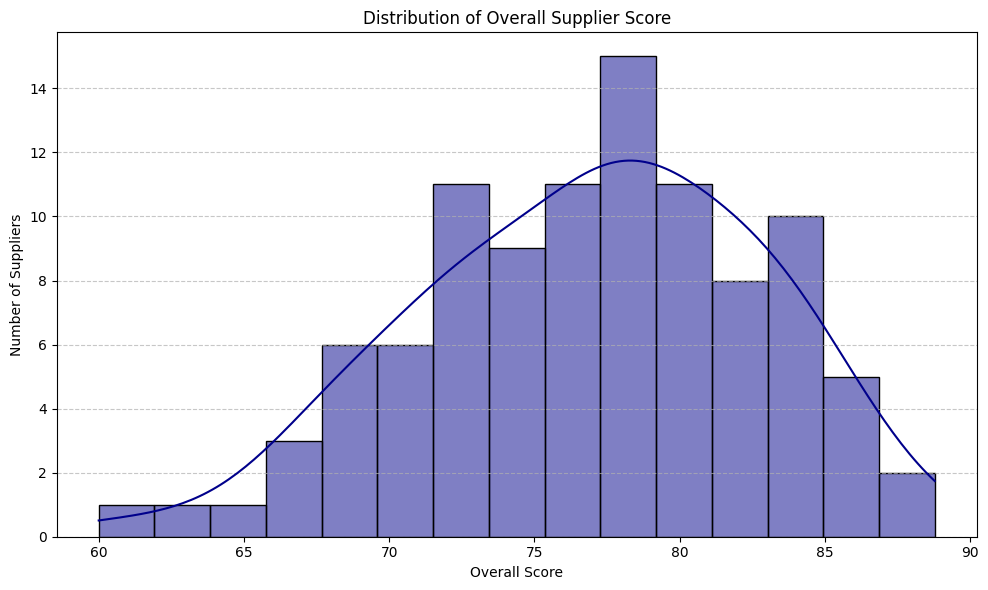

In [40]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Overall_Score'], kde=True, bins=15, color='darkblue')
plt.title('Distribution of Overall Supplier Score')
plt.xlabel('Overall Score')
plt.ylabel('Number of Suppliers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

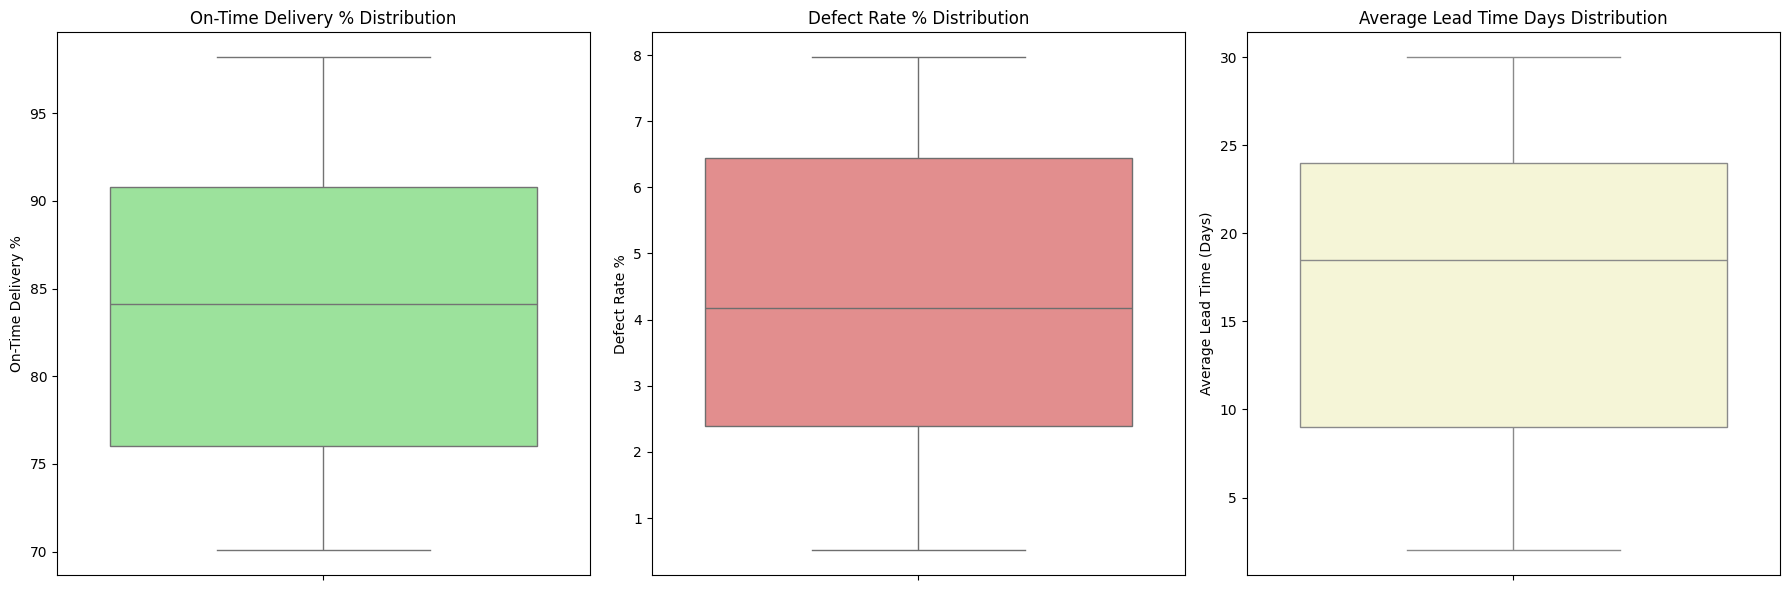

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=df['On_Time_Delivery_%'], ax=axes[0], color='lightgreen')
axes[0].set_title('On-Time Delivery % Distribution')
axes[0].set_ylabel('On-Time Delivery %')

sns.boxplot(y=df['Defect_Rate_%'], ax=axes[1], color='lightcoral')
axes[1].set_title('Defect Rate % Distribution')
axes[1].set_ylabel('Defect Rate %')

sns.boxplot(y=df['Avg_Lead_Time_Days'], ax=axes[2], color='lightgoldenrodyellow')
axes[2].set_title('Average Lead Time Days Distribution')
axes[2].set_ylabel('Average Lead Time (Days)')

plt.tight_layout()
plt.show()

The dataset shows a wide distribution of supplier performance across operational, quality, and compliance metrics. Some suppliers consistently outperform others in delivery reliability and defect control, indicating clear segmentation potential for ranking and classification.

#Supplier Ranking System

This section outlines the development of a unified supplier ranking system. By combining multiple KPIs into a weighted composite score, we aim to provide a fair and objective comparison of suppliers based on various performance aspects like delivery, quality, cost, risk, and compliance.

**Objective**

To build a unified supplier ranking system by combining multiple KPIs into a weighted composite score. This allows fair comparison across suppliers based on delivery, quality, cost efficiency, risk, and compliance.

In [24]:
from sklearn.preprocessing import MinMaxScaler

# Clean risk column + map
df["Supplier_Risk_Level"] = df["Supplier_Risk_Level"].astype(str).str.strip().str.title()

df["Risk_Score"] = df["Supplier_Risk_Level"].map({
    "Low": 3,
    "Medium": 2,
    "High": 1
}).fillna(2)


# Columns to scale
cols_to_scale = [
    "On_Time_Delivery_%",
    "Fill_Rate_%",
    "Contract_Compliance_%",
    "Sustainability_Score",
    "Avg_Lead_Time_Days",
    "Defect_Rate_%",
    "Response_Time_Hours",
    "Cost_per_Unit",
    "Risk_Score"
]

# Handle missing values
df[cols_to_scale] = df[cols_to_scale].fillna(df[cols_to_scale].median())

# Scale data
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Inverse metrics
df_scaled["Lead_Time_Score"] = 1 - df_scaled["Avg_Lead_Time_Days"]
df_scaled["Defect_Score"] = 1 - df_scaled["Defect_Rate_%"]
df_scaled["Cost_Score"] = 1 - df_scaled["Cost_per_Unit"]

# Final score
df_scaled["Supplier_Score"] = (
    0.25 * df_scaled["On_Time_Delivery_%"] +
    0.20 * df_scaled["Fill_Rate_%"] +
    0.15 * df_scaled["Contract_Compliance_%"] +
    0.10 * df_scaled["Sustainability_Score"] +
    0.10 * df_scaled["Lead_Time_Score"] +
    0.10 * df_scaled["Defect_Score"] +
    0.05 * df_scaled["Cost_Score"] +
    0.05 * df_scaled["Risk_Score"]
)

# Ranking
df_scaled["Rank"] = df_scaled["Supplier_Score"].rank(ascending=False)

df_scaled.sort_values("Supplier_Score", ascending=False)[
    ["Supplier_ID", "Supplier_Name", "Supplier_Score", "Rank"]
].head(10)

,Supplier_ID,Supplier_Name,Supplier_Score,Rank
59,SUP060,Lopez Inc,0.845772,1.0
4,SUP005,Reyes LLC,0.752818,2.0
27,SUP028,"Sweeney, Carson and Case",0.681773,3.0
21,SUP022,King-Hall,0.659051,4.0
76,SUP077,Sullivan-Underwood,0.650100,5.0
30,SUP031,Gray Inc,0.641925,6.0
6,SUP007,"Cook, Soto and Black",0.633114,7.0
99,SUP100,"Harris, Fox and Douglas",0.628279,8.0
60,SUP061,"Gray, Ali and Taylor",0.625670,9.0
83,SUP084,"Francis, Clark and Brandt",0.623305,10.0


# Supplier Performance Dashboard

This part of the notebook is dedicated to visualizing supplier performance. We will create a dashboard with key charts to highlight top and bottom performers, compare KPIs, and analyze regional performance, transforming analysis into actionable insights.

**We will create 4 core visuals:**

Top 10 suppliers (bar chart)

Bottom 10 suppliers (bar chart)

KPI comparison (high vs low performers)

Regional supplier performance

**This turns your project from “analysis” → decision system**

**Top 10 Suppliers**

/tmp/ipykernel_1555/169699488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Supplier_Name", y="Supplier_Score", data=top_ten_supplier_score, palette="viridis")


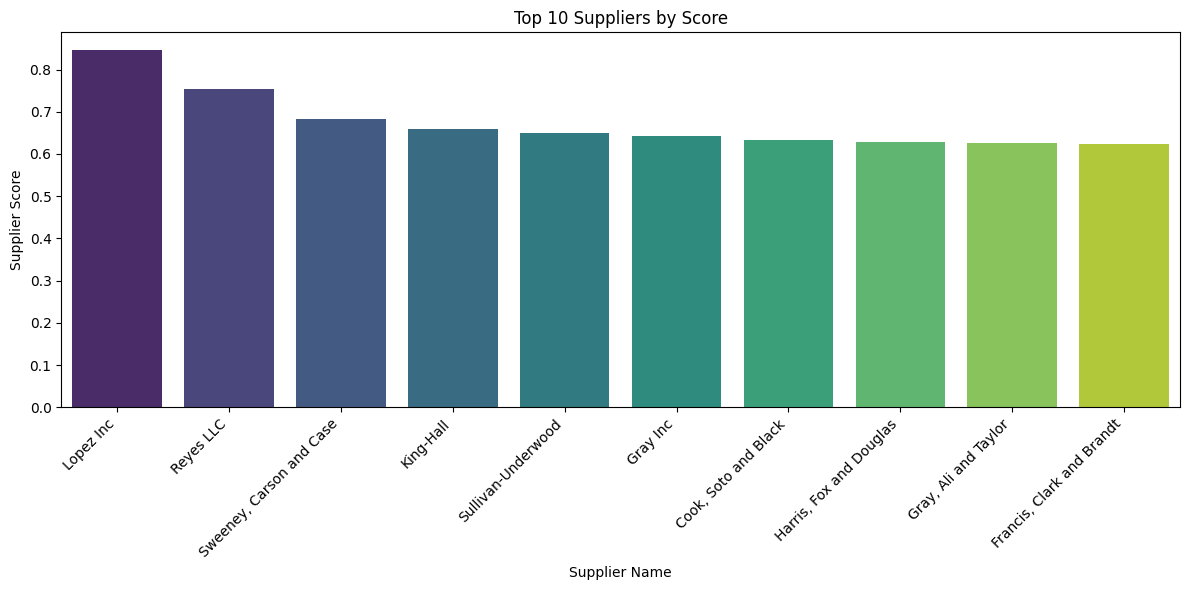

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

top_ten_supplier_score = df_scaled.sort_values("Supplier_Score", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x="Supplier_Name", y="Supplier_Score", data=top_ten_supplier_score, palette="viridis")
plt.title("Top 10 Suppliers by Score")
plt.xlabel("Supplier Name")
plt.ylabel("Supplier Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Bottom 10 Suppliers**

/tmp/ipykernel_1555/785711410.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Supplier_Name", y="Supplier_Score", data=bottom_ten_supplier_score, palette="viridis")


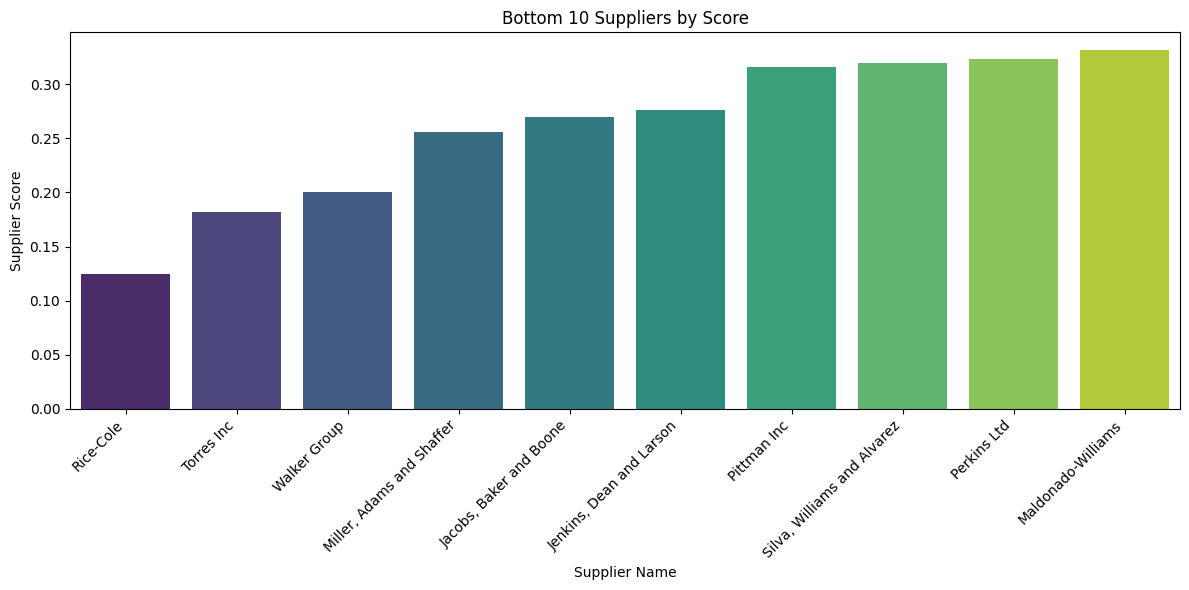

In [26]:
bottom_ten_supplier_score = df_scaled.sort_values("Supplier_Score", ascending=True).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x="Supplier_Name", y="Supplier_Score", data=bottom_ten_supplier_score, palette="viridis")
plt.title("Bottom 10 Suppliers by Score")
plt.xlabel("Supplier Name")
plt.ylabel("Supplier Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**KPI Comparison (High vs. Low Performers)**

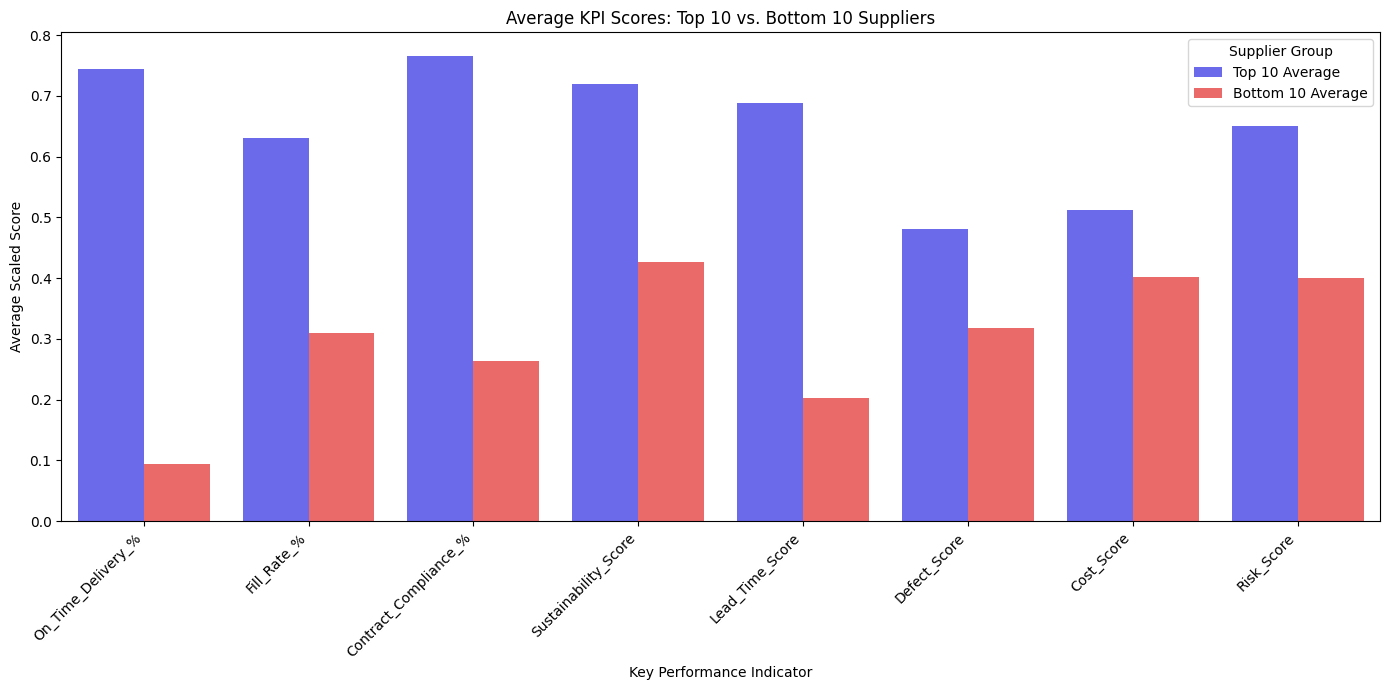

In [27]:
kpi_columns_for_comparison = [
    "On_Time_Delivery_%",
    "Fill_Rate_%",
    "Contract_Compliance_%",
    "Sustainability_Score",
    "Lead_Time_Score",
    "Defect_Score",
    "Cost_Score",
    "Risk_Score"
]

# Calculate average KPI scores for top 10 and bottom 10 suppliers
avg_top_10_kpis = top_ten_supplier_score[kpi_columns_for_comparison].mean()
avg_bottom_10_kpis = bottom_ten_supplier_score[kpi_columns_for_comparison].mean()

# Create a DataFrame for comparison
kpi_comparison_df = pd.DataFrame({
    'KPI': kpi_columns_for_comparison,
    'Top 10 Average': avg_top_10_kpis.values,
    'Bottom 10 Average': avg_bottom_10_kpis.values
})

# Melt the DataFrame for seaborn barplot
kpi_comparison_melted = kpi_comparison_df.melt(id_vars='KPI', var_name='Supplier Group', value_name='Average Score')

plt.figure(figsize=(14, 7))
sns.barplot(x='KPI', y='Average Score', hue='Supplier Group', data=kpi_comparison_melted, palette='seismic')
plt.title('Average KPI Scores: Top 10 vs. Bottom 10 Suppliers')
plt.xlabel('Key Performance Indicator')
plt.ylabel('Average Scaled Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Supplier Group')
plt.tight_layout()
plt.show()

**Regional Supplier Performance**

/tmp/ipykernel_1555/2641303585.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Supplier_Score', data=regional_performance, palette='plasma')


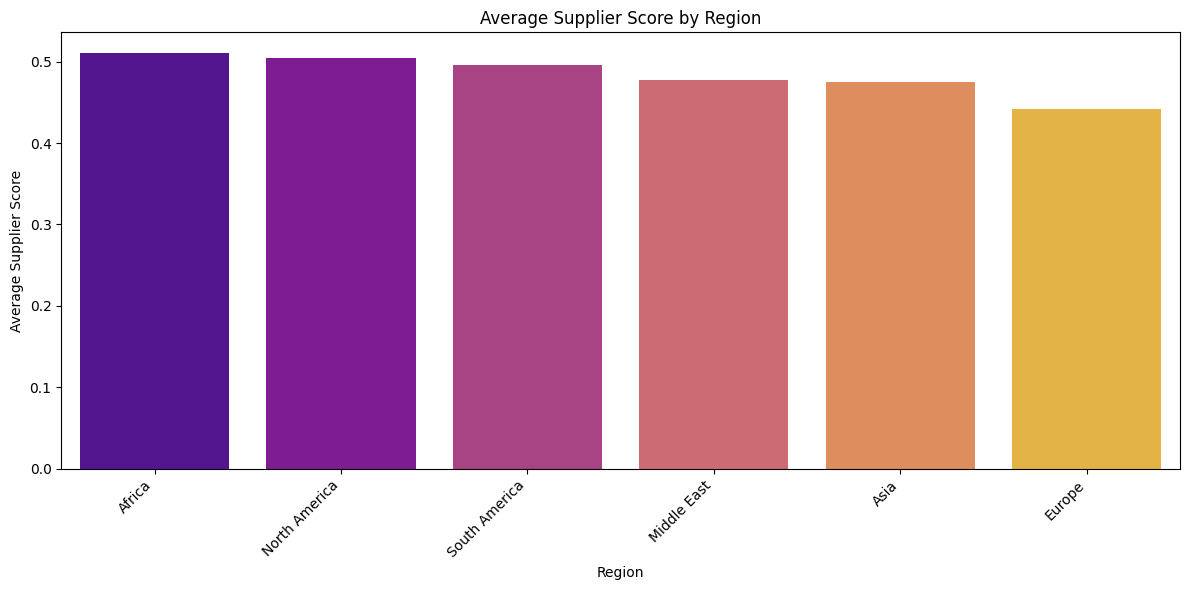

In [28]:
# Calculate average Supplier_Score per Region
regional_performance = df_scaled.groupby('Region')['Supplier_Score'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='Supplier_Score', data=regional_performance, palette='plasma')
plt.title('Average Supplier Score by Region')
plt.xlabel('Region')
plt.ylabel('Average Supplier Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Supplier performance is uneven across vendors, indicating strong segmentation potential.
Top suppliers show consistently higher delivery reliability and lower defect rates.
Bottom suppliers underperform primarily in lead time and quality metrics.
Regional differences suggest supply chain maturity varies geographically.

# Summary

This final section summarizes the approach taken, key findings from the analysis, and strategic insights derived. It highlights the business impact of the developed model in enabling data-driven supplier selection and improving supply chain management.

**Approach**

A composite supplier scoring model was built using normalized KPIs:

Delivery performance

Quality performance

Operational efficiency

Cost efficiency

Risk profile

Sustainability metrics

Each supplier was assigned a weighted score and ranked accordingly.

**Key Findings**
1. Supplier segmentation is clear

Suppliers naturally fall into:

High performers (top tier)
Average performers (mid tier)
Underperformers (risk group)

2. Performance drivers

Top suppliers consistently show:

Higher on-time delivery
Lower defect rates
Better compliance behavior

3. Risk concentration exists

A subset of suppliers contributes disproportionately to operational inefficiencies and variability.

**Strategic Insights**

Procurement should prioritize top-tier suppliers for long-term contracts.

Underperforming suppliers require corrective action or replacement.

Regional differences indicate uneven supply chain maturity.

Quality and delivery reliability are stronger performance drivers than cost alone.
Business Impact

**This model enables:**

Data-driven supplier selection

Reduced supply chain risk

Improved service levels

Better negotiation leverage

Structured vendor governance

In [29]:
# Convert that XLSX file to CSV file
df.to_csv('vendor_performance.csv', index=False)